# Core — data snooping in the synthetic lab

Story notebook. Three artifacts:

1. **Cleanest snooping demo** — Case 1 (random labels): truth = 0.5 by construction, so `gap = best_val − 0.5` is pure luck.
2. **Headline figure** — apparent (best validation) vs true (sealed test) as the search size N grows.
3. **The isometry insight** — kNN / logistic / SVM unchanged between Case 2 and Case 3; only the tree degrades.

## Setup
Run Jupyter from the repo root. The first code cell adds the repo root to `sys.path` and imports from `snooping_backend`. (You implement the cells.)

In [1]:
import sys, os
ROOT = os.getcwd()
while not os.path.isdir(os.path.join(ROOT, "snooping_backend")) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)            # walk up to the repo root (holds snooping_backend/)
sys.path.insert(0, ROOT)

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from snooping_backend.lab import make_dataset
from snooping_backend.mlp import train, accuracy
from snooping_backend.pipeline import run_once, sweep

D = 20
SIZES = [1000, 200, 20000]    # train, SMALL validation (the snoop), LARGE sealed test (the truth)

## E0 — the network learns (loss vs epoch)
A sanity check that the MLP trains: on Case 2 (a learnable signal) the training loss falls.

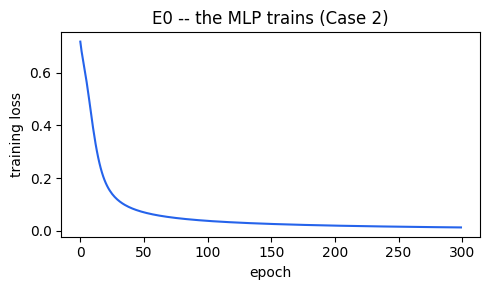

loss: 0.717 (start)  ->  0.013 (end)


In [2]:
# E0 -- the network learns: on Case 2 (a learnable signal) the training loss falls.
(X_tr, y_tr), _, _ = make_dataset(2, D, 0.0, SIZES, np.random.default_rng(0))
_, losses = train(X_tr, y_tr, width=32, lr=0.5, epochs=300, seed=0, return_loss=True)

plt.figure(figsize=(5, 3))
plt.plot(losses, color="#2563eb")
plt.xlabel("epoch"); plt.ylabel("training loss"); plt.title("E0 -- the MLP trains (Case 2)")
plt.tight_layout(); plt.show()
print(f"loss: {losses[0]:.3f} (start)  ->  {losses[-1]:.3f} (end)")

## 1. Cleanest snooping demo — Case 1 (random labels)

In [3]:
# Case 1 = random labels, so the TRUE performance of any model is 0.5 by construction.
# Search N configs, keep the best on the SMALL validation set, then reveal the truth once.
rng = np.random.default_rng(1)
print(f"{'N':>4}   apparent    true     gap")
for N in [1, 10, 50]:
    r = run_once(1, N, SIZES, D, 0.0, rng, epochs=40)
    print(f"{N:>4}      {r['apparent']:.3f}   {r['true']:.3f}   {r['gap']:+.3f}")
print("\nTrue stays ~0.5 (no signal); apparent climbs with N -- the winner's curse.")

   N   apparent    true     gap
   1      0.470   0.500   -0.030


  10      0.550   0.498   +0.052


  50      0.600   0.505   +0.095

True stays ~0.5 (no signal); apparent climbs with N -- the winner's curse.


## 2. Headline figure — gap vs N

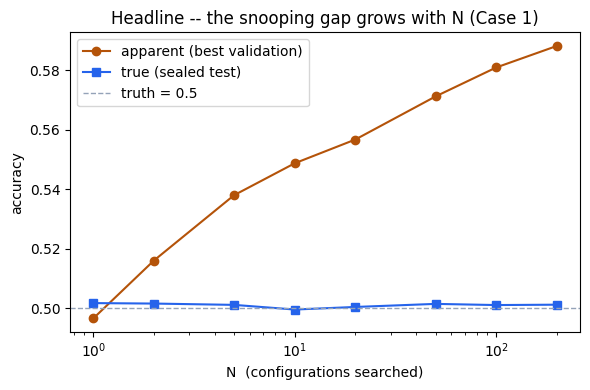

   N     gap    (std)
   1   -0.005   (0.035)
   2   +0.014   (0.025)
   5   +0.037   (0.024)
  10   +0.049   (0.019)
  20   +0.056   (0.016)
  50   +0.070   (0.014)
 100   +0.080   (0.017)
 200   +0.087   (0.014)


In [4]:
# Headline: the snooping gap grows with N on Case 1.
N_values = [1, 2, 5, 10, 20, 50, 100, 200]
res = sweep(1, N_values, SIZES, D, 0.0, np.random.default_rng(0), R=20, epochs=40)

apparent = [res[N]["apparent"] for N in N_values]
true     = [res[N]["true"]     for N in N_values]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(N_values, apparent, "o-", color="#b45309", label="apparent (best validation)")
ax.plot(N_values, true,     "s-", color="#2563eb", label="true (sealed test)")
ax.axhline(0.5, ls="--", lw=1, color="#94a3b8", label="truth = 0.5")
ax.set_xscale("log")
ax.set_xlabel("N  (configurations searched)"); ax.set_ylabel("accuracy")
ax.set_title("Headline -- the snooping gap grows with N (Case 1)")
ax.legend(); fig.tight_layout()
fig.savefig(os.path.join(ROOT, "figures", "headline_gap_vs_N.svg"))
plt.show()

print(f"{'N':>4}     gap    (std)")
for N in N_values:
    print(f"{N:>4}   {res[N]['gap']:+.3f}   ({res[N]['gap_std']:.3f})")

## 3. Isometry insight — Case 2 vs Case 3

In [5]:
# Support track (after the gate): the sklearn garden (kNN / tree / logreg / SVM)
# on Case 2 vs Case 3 -- kNN/logreg/SVM unchanged, only the axis-aligned tree drops.
# Filled when the sklearn support models land (Core.md SS5, artifact 3).